# TSCV 多折交叉验证评估

扫描 `model/TSCV/` 目录，汇总所有已完成的 TSCV 实验结果，筛选最优模型。

评分指标: `cv_score = mean_sharpe - std_sharpe`

In [52]:
import os, sys, json, glob
import pandas as pd
import numpy as np

sys.path.insert(0, '../code/src')
import warnings
warnings.filterwarnings('ignore')

TSCV_DIR = "../model/TSCV"

## 1. 加载 TSCV 结果

In [53]:
rows = []
for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
    model_type = os.path.basename(os.path.normpath(mt_dir))
    parts = model_type.split("_")
    mt_short = parts[1] if len(parts) >= 2 else model_type

    for exp_dir in sorted(glob.glob(f"{mt_dir}exp_*/")):
        result_file = os.path.join(exp_dir, "tscv_results.json")
        config_file = os.path.join(exp_dir, "config.json")
        if not os.path.exists(result_file):
            continue
        with open(result_file) as f:
            r = json.load(f)
        if not r.get("success"):
            continue

        exp_idx = int(os.path.basename(os.path.normpath(exp_dir)).split("_")[1])
        folds_done = sum(1 for d in sorted(glob.glob(f"{exp_dir}fold_*/"))
                        if os.path.exists(os.path.join(d, "epoch_scores.txt")))
        folds_total = len(r.get("fold_sharpe", []))
        params = r.get("params", {})

        row = {
            "model_type": mt_short,
            "exp_idx": exp_idx,
            "cv_score": r.get("cv_score", r.get("sharpe", 0)),
            "mean_sharpe": r.get("mean_sharpe", 0),
            "std_sharpe": r.get("std_sharpe", 0),
            "mean_calmar": r.get("mean_calmar", 0),
            "mean_max_dd": r.get("mean_max_dd", 0),
            "mean_sortino": r.get("mean_sortino", 0),
            "mean_win_rate": r.get("mean_win_rate", 0),
            "folds_done": folds_done,
            "folds_total": folds_total,
            "lr": params.get("learning_rate", 0),
            "d_model": params.get("d_model", 0),
            "dropout": params.get("dropout", 0),
            "num_layers": params.get("num_layers", 0),
            "kernel_size": params.get("kernel_size", 0),
        }
        rows.append(row)

df = pd.DataFrame(rows) if rows else pd.DataFrame()
print(f"共加载 {len(df)} 个实验")
if len(df) > 0:
    display(df[['model_type', 'exp_idx', 'cv_score', 'mean_sharpe', 'std_sharpe',
                'mean_max_dd', 'mean_sortino', 'mean_win_rate',
                'folds_done', 'folds_total']].sort_values(by=['cv_score'], ascending=[False]))

共加载 86 个实验


,model_type,exp_idx,cv_score,mean_sharpe,std_sharpe,mean_max_dd,mean_sortino,mean_win_rate,folds_done,folds_total
2,dlinear,11,2.311428,2.589850,0.278422,8.891675,4.251050,0.596400,4,4
26,dlinear,6,2.075952,2.383400,0.307448,9.046550,3.951200,0.528700,4,4
61,tcn,31,2.040979,2.808500,0.767521,7.819450,4.947100,0.685050,4,4
77,tcn,49,2.022712,2.753100,0.730388,9.098500,4.519175,0.782625,4,4
46,tcn,17,1.947278,2.427600,0.480322,8.909125,3.965400,0.549450,4,4
...,...,...,...,...,...,...,...,...,...,...
65,tcn,37,0.553043,1.775450,1.222407,16.305625,3.174250,0.608900,4,4
21,dlinear,2,0.506466,1.380700,0.874234,12.070800,2.386250,0.538400,4,4
66,tcn,38,0.481883,1.778225,1.296342,12.608775,3.032700,0.584875,4,4
16,dlinear,25,0.464729,1.444050,0.979321,16.388900,2.561600,0.536100,4,4


## 2. 实验综合排名


### 2.1 按 CV Score 排名

按 `cv_score = mean_sharpe - std_sharpe` 排序。


,rank,model_type,exp_idx,cv_score,mean_sharpe,std_sharpe,mean_max_dd,mean_sortino,mean_win_rate
0,1,dlinear,11,2.311428,2.589850,0.278422,8.891675,4.251050,0.596400
1,2,dlinear,6,2.075952,2.383400,0.307448,9.046550,3.951200,0.528700
2,3,tcn,31,2.040979,2.808500,0.767521,7.819450,4.947100,0.685050
3,4,tcn,49,2.022712,2.753100,0.730388,9.098500,4.519175,0.782625
4,5,tcn,17,1.947278,2.427600,0.480322,8.909125,3.965400,0.549450
...,...,...,...,...,...,...,...,...,...
81,82,tcn,37,0.553043,1.775450,1.222407,16.305625,3.174250,0.608900
82,83,dlinear,2,0.506466,1.380700,0.874234,12.070800,2.386250,0.538400
83,84,tcn,38,0.481883,1.778225,1.296342,12.608775,3.032700,0.584875
84,85,dlinear,25,0.464729,1.444050,0.979321,16.388900,2.561600,0.536100


,model_type,exp_idx,cv_score,mean_sharpe,std_sharpe,mean_calmar,mean_max_dd,mean_sortino,mean_win_rate,folds_done,folds_total,lr,d_model,dropout,num_layers,kernel_size,rank
0,dlinear,11,2.311428,2.589850,0.278422,8.335225,8.891675,4.251050,0.596400,4,4,0.000305,128,0.173320,1,25,1
1,dlinear,6,2.075952,2.383400,0.307448,8.843125,9.046550,3.951200,0.528700,4,4,0.000405,128,0.196563,1,25,2
2,tcn,31,2.040979,2.808500,0.767521,11.109100,7.819450,4.947100,0.685050,4,4,0.000084,64,0.180631,3,3,3
3,tcn,49,2.022712,2.753100,0.730388,9.143000,9.098500,4.519175,0.782625,4,4,0.000270,64,0.182664,3,3,4
4,tcn,17,1.947278,2.427600,0.480322,7.985550,8.909125,3.965400,0.549450,4,4,0.000300,128,0.184733,4,3,5
5,tcn,42,1.871937,2.416050,0.544113,8.347200,11.582575,3.917125,0.775925,4,4,0.000254,64,0.192618,3,3,6
6,tcn,34,1.869700,2.417975,0.548275,0.000000,0.000000,0.000000,0.000000,4,4,0.000083,64,0.199796,3,3,7
7,tcn,39,1.856209,2.668300,0.812091,9.341975,11.586575,4.365325,0.683625,4,4,0.000111,64,0.189642,3,3,8
8,tcn,28,1.844124,2.641950,0.797826,11.665575,10.487450,4.740500,0.723675,4,4,0.000058,64,0.180486,3,3,9
9,dlinear,14,1.807612,2.080200,0.272588,6.262625,10.880100,3.394725,0.534900,4,4,0.000222,128,0.177966,1,25,10


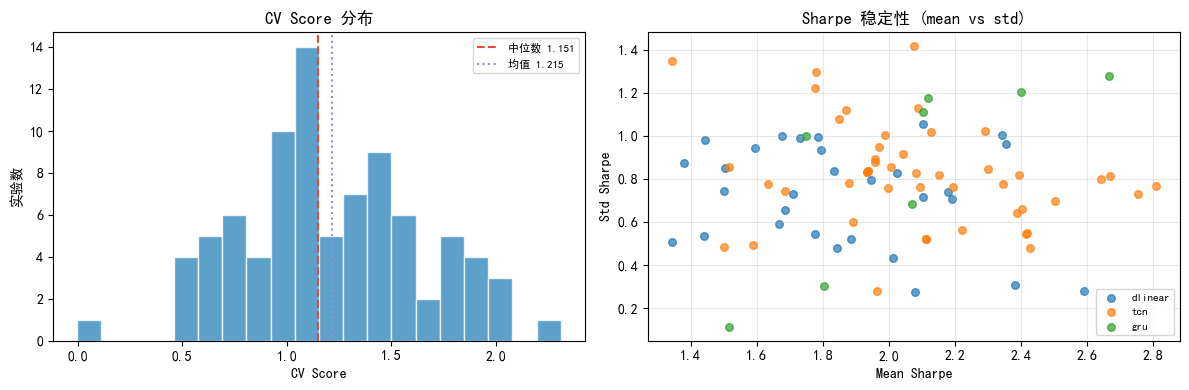

In [54]:
if len(df) > 0:
    ranked = df.sort_values('cv_score', ascending=False).reset_index(drop=True)
    ranked['rank'] = range(1, len(ranked) + 1)
    cols = ['rank', 'model_type', 'exp_idx', 'cv_score',
            'mean_sharpe', 'std_sharpe', 'mean_max_dd', 'mean_sortino', 'mean_win_rate']
    display(ranked[cols])

    # 分位数着色排名表
    def _highlight(val, col_name, table):
        higher_better = ('cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate')
        lower_better = ('std_sharpe', 'mean_max_dd')
        if col_name in higher_better:
            if val >= table[col_name].quantile(0.8):
                return 'background-color: #006837; color: white'
            elif val >= table[col_name].quantile(0.6):
                return 'background-color: #2aa054; color: white'
            elif val >= table[col_name].quantile(0.4):
                return 'background-color: #7fc866'
            else:
                return 'background-color: #f1f9ac'
        elif col_name in lower_better:
            if val <= table[col_name].quantile(0.2):
                return 'background-color: #006837; color: white'
            elif val <= table[col_name].quantile(0.4):
                return 'background-color: #2aa054; color: white'
            elif val <= table[col_name].quantile(0.6):
                return 'background-color: #7fc866'
            else:
                return 'background-color: #f1f9ac'
        return ''
    styled = ranked.style.map(lambda v: _highlight(v, 'cv_score', ranked), subset=['cv_score'])
    styled = styled.map(lambda v: _highlight(v, 'std_sharpe', ranked), subset=['std_sharpe'])
    styled = styled.map(lambda v: _highlight(v, 'mean_max_dd', ranked), subset=['mean_max_dd'])
    styled = styled.map(lambda v: _highlight(v, 'mean_sharpe', ranked), subset=['mean_sharpe'])
    styled = styled.map(lambda v: _highlight(v, 'mean_sortino', ranked), subset=['mean_sortino'])
    styled = styled.map(lambda v: _highlight(v, 'mean_win_rate', ranked), subset=['mean_win_rate'])
    display(styled)

    # CV Score 分布直方图
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.hist(ranked['cv_score'], bins=20, color='#348ABD', edgecolor='white', alpha=0.8)
    ax.axvline(ranked['cv_score'].median(), color='#E24A33', linestyle='--', label=f"中位数 {ranked['cv_score'].median():.3f}")
    ax.axvline(ranked['cv_score'].mean(), color='#988ED5', linestyle=':', label=f"均值 {ranked['cv_score'].mean():.3f}")
    ax.set_xlabel('CV Score')
    ax.set_ylabel('实验数')
    ax.set_title('CV Score 分布')
    ax.legend(fontsize=8)

    ax = axes[1]
    for mt in ranked['model_type'].unique():
        sub = ranked[ranked['model_type'] == mt]
        ax.scatter(sub['mean_sharpe'], sub['std_sharpe'], label=mt, s=30, alpha=0.7)
    ax.set_xlabel('Mean Sharpe')
    ax.set_ylabel('Std Sharpe')
    ax.set_title('Sharpe 稳定性 (mean vs std)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
else:
    print("暂无完成的 TSCV 结果")

### 2.2 按综合评分排名

对每个指标计算分位数评分（0-1），加权求和得到综合评分。
越高越好的指标: cv_score, mean_sharpe, mean_sortino, mean_win_rate
越低越好的指标: std_sharpe, mean_max_dd


,rank,model_type,exp_idx,composite_score,q_cv_score,q_mean_sharpe,q_mean_sortino,q_mean_win_rate,q_std_sharpe,q_mean_max_dd,cv_score,mean_sharpe,mean_sortino,mean_win_rate,std_sharpe,mean_max_dd
0,1,tcn,49,0.893411,0.965116,0.988372,0.965116,0.965116,0.639535,0.837209,2.022712,2.753100,4.519175,0.782625,0.730388,9.098500
1,2,dlinear,11,0.883721,1.000000,0.941860,0.930233,0.604651,0.953488,0.872093,2.311428,2.589850,4.251050,0.596400,0.278422,8.891675
2,3,tcn,31,0.874031,0.976744,1.000000,1.000000,0.767442,0.558140,0.941860,2.040979,2.808500,4.947100,0.685050,0.767521,7.819450
3,4,tcn,7,0.844961,0.837209,0.767442,0.813953,0.930233,0.767442,0.953488,1.662088,2.222975,3.852900,0.769200,0.560887,6.017925
4,5,tcn,42,0.821705,0.941860,0.895349,0.860465,0.941860,0.790698,0.500000,1.871937,2.416050,3.917125,0.775925,0.544113,11.582575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,82,dlinear,2,0.207364,0.046512,0.034884,0.127907,0.279070,0.325581,0.430233,0.506466,1.380700,2.386250,0.538400,0.874234,12.070800
82,83,dlinear,30,0.191860,0.069767,0.093023,0.209302,0.081395,0.360465,0.337209,0.651691,1.504300,2.731650,0.515525,0.852609,12.638575
83,84,tcn,50,0.174419,0.011628,0.023256,0.046512,0.744186,0.011628,0.209302,-0.003570,1.344950,2.018925,0.680825,1.348520,14.680500
84,85,dlinear,26,0.170543,0.081395,0.139535,0.232558,0.116279,0.267442,0.186047,0.651751,1.595550,2.786550,0.523000,0.943799,14.930650


,model_type,exp_idx,cv_score,mean_sharpe,mean_sortino,mean_win_rate,std_sharpe,mean_max_dd,q_cv_score,q_mean_sharpe,q_mean_sortino,q_mean_win_rate,q_std_sharpe,q_mean_max_dd,composite_score,rank
0,tcn,49,2.022712,2.753100,4.519175,0.782625,0.730388,9.098500,0.965116,0.988372,0.965116,0.965116,0.639535,0.837209,0.893411,1
1,dlinear,11,2.311428,2.589850,4.251050,0.596400,0.278422,8.891675,1.000000,0.941860,0.930233,0.604651,0.953488,0.872093,0.883721,2
2,tcn,31,2.040979,2.808500,4.947100,0.685050,0.767521,7.819450,0.976744,1.000000,1.000000,0.767442,0.558140,0.941860,0.874031,3
3,tcn,7,1.662088,2.222975,3.852900,0.769200,0.560887,6.017925,0.837209,0.767442,0.813953,0.930233,0.767442,0.953488,0.844961,4
4,tcn,42,1.871937,2.416050,3.917125,0.775925,0.544113,11.582575,0.941860,0.895349,0.860465,0.941860,0.790698,0.500000,0.821705,5
5,tcn,17,1.947278,2.427600,3.965400,0.549450,0.480322,8.909125,0.953488,0.918605,0.883721,0.360465,0.895349,0.860465,0.812016,6
6,tcn,29,1.745326,2.387375,4.203400,0.628075,0.642049,9.343250,0.872093,0.848837,0.918605,0.639535,0.732558,0.813953,0.804264,7
7,tcn,28,1.844124,2.641950,4.740500,0.723675,0.797826,10.487450,0.906977,0.953488,0.976744,0.837209,0.500000,0.616279,0.798450,8
8,tcn,26,1.806890,2.503375,4.085525,0.732325,0.696485,12.176150,0.883721,0.930233,0.906977,0.872093,0.686047,0.406977,0.781008,9
9,dlinear,6,2.075952,2.383400,3.951200,0.528700,0.307448,9.046550,0.988372,0.837209,0.872093,0.162791,0.930233,0.848837,0.773256,10


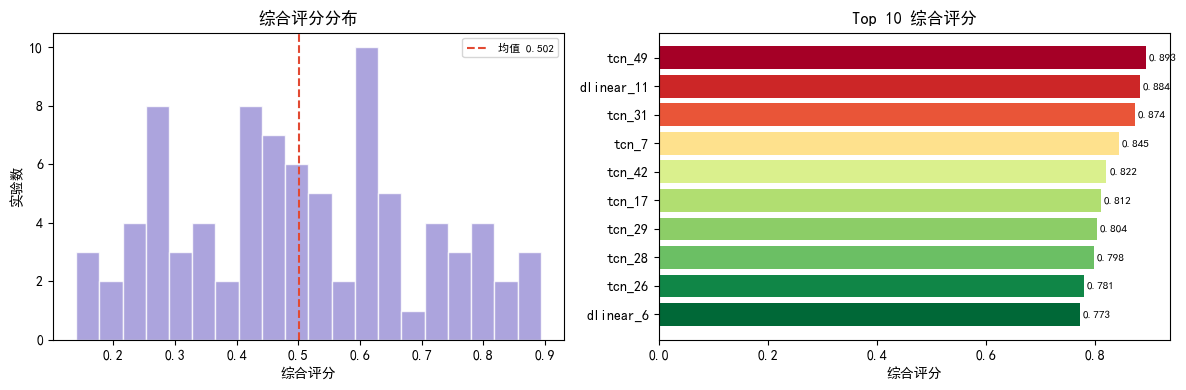

In [55]:
if len(df) > 0:
    # 分位数综合评分
    higher_better = ['cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate']
    lower_better = ['std_sharpe', 'mean_max_dd']

    composite = df[['model_type', 'exp_idx'] + higher_better + lower_better].copy()
    for col in higher_better:
        composite[f'q_{col}'] = composite[col].rank(pct=True)
    for col in lower_better:
        composite[f'q_{col}'] = 1 - composite[col].rank(pct=True)

    q_cols = [f'q_{c}' for c in higher_better + lower_better]
    composite['composite_score'] = composite[q_cols].mean(axis=1)
    composite = composite.sort_values('composite_score', ascending=False).reset_index(drop=True)
    composite['rank'] = range(1, len(composite) + 1)

    display_cols = ['rank', 'model_type', 'exp_idx', 'composite_score'] + [f'q_{c}' for c in higher_better + lower_better] + higher_better + lower_better
    display(composite[display_cols])

    # 分位数着色
    def _highlight_all(val, col_name, table):
        if col_name.startswith('q_'):
            if val >= 0.8:
                return 'background-color: #006837; color: white'
            elif val >= 0.6:
                return 'background-color: #2aa054; color: white'
            elif val >= 0.4:
                return 'background-color: #7fc866'
            else:
                return 'background-color: #f1f9ac'
        return ''
    styled = composite.style.map(lambda v: _highlight_all(v, 'composite_score', composite), subset=['composite_score'])
    for col in q_cols:
        styled = styled.map(lambda v, c=col: _highlight_all(v, c, composite), subset=[col])
    display(styled)

    # 综合评分分布
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax = axes[0]
    ax.hist(composite['composite_score'], bins=20, color='#988ED5', edgecolor='white', alpha=0.8)
    ax.axvline(composite['composite_score'].mean(), color='#E24A33', linestyle='--', label=f"均值 {composite['composite_score'].mean():.3f}")
    ax.set_xlabel('综合评分')
    ax.set_ylabel('实验数')
    ax.set_title('综合评分分布')
    ax.legend(fontsize=8)

    ax = axes[1]
    top10 = composite.head(10)
    colors = plt.cm.RdYlGn(1 - (top10['composite_score'] - top10['composite_score'].min()) / (top10['composite_score'].max() - top10['composite_score'].min() + 1e-8))
    ax.barh(range(len(top10)), top10['composite_score'], color=colors)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels([f"{r['model_type']}_{r['exp_idx']}" for _, r in top10.iterrows()])
    ax.set_xlabel('综合评分')
    ax.set_title('Top 10 综合评分')
    ax.invert_yaxis()
    for i, v in enumerate(top10['composite_score']):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    # 各模型类别综合评分分布
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    ax = axes[0]
    mt_labels = sorted(composite['model_type'].unique())
    mt_groups = [composite[composite['model_type'] == mt]['composite_score'] for mt in mt_labels]

    vp = ax.violinplot(mt_groups, positions=range(len(mt_labels)), showmeans=True, showmedians=True)
    for i, body in enumerate(vp['bodies']):
        body.set_facecolor(plt.cm.tab10(i % 10))
        body.set_alpha(0.6)
    vp['cmeans'].set_color('#E24A33')
    vp['cmedians'].set_color('#2aa054')
    ax.set_xticks(range(len(mt_labels)))
    ax.set_xticklabels(mt_labels)
    ax.set_xlabel('模型类型')
    ax.set_ylabel('综合评分')
    ax.set_title('各模型类型综合评分分布 (小提琴图)')
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[1]
    mt_avg = composite.groupby('model_type')[q_cols].mean()
    im = ax.imshow(mt_avg.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(q_cols)))
    ax.set_xticklabels([c.replace('q_', '') for c in q_cols], rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(mt_avg)))
    ax.set_yticklabels(mt_avg.index, fontsize=8)
    ax.set_title('各模型类型分位数得分均值')
    for i in range(len(mt_avg)):
        for j in range(len(q_cols)):
            v = mt_avg.values[i, j]
            color = 'white' if v > 0.5 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=color)
    plt.colorbar(im, ax=ax, shrink=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("暂无完成的 TSCV 结果")

## 3. 模型优选


In [56]:
if len(df) > 0 and 'mean_max_dd' in df.columns:
    score_df = df.copy()
    score_df['score'] = (score_df['mean_sharpe'] ** 2 /
                         score_df['mean_max_dd'].abs().replace(0, 1e-8) *
                         (1 + score_df['mean_sharpe'] / 100))

    print("=" * 70)
    print("模型选择结果")
    print("=" * 70)

    best_per_type = []
    for mt in score_df['model_type'].unique():
        sub = score_df[score_df['model_type'] == mt]
        threshold = sub['cv_score'].quantile(0.85)
        top_group = sub[sub['cv_score'] >= threshold].copy()
        if len(top_group) == 0:
            top_group = sub.nlargest(max(1, len(sub) // 5), 'cv_score')
        top_group = top_group.sort_values('score', ascending=False)
        best = top_group.iloc[0]
        best_per_type.append(best)

        # 离群检验: 检查该实验在同类型中是否严重偏离
        q1, q3 = sub['cv_score'].quantile(0.25), sub['cv_score'].quantile(0.75)
        iqr = q3 - q1
        outlier_upper = q3 + 3.0 * iqr
        outlier_lower = q1 - 3.0 * iqr
        is_outlier = best['cv_score'] > outlier_upper

        print(f"\n{mt.upper()}:")
        print(f"  Best: exp_{int(best['exp_idx'])}  cv_score={best['cv_score']:.4f}")
        print(f"  mean_sharpe={best['mean_sharpe']:.4f}  std_sharpe={best['std_sharpe']:.4f}")
        print(f"  mean_max_dd={best['mean_max_dd']:.2f}%  mean_sortino={best['mean_sortino']:.2f}  mean_win_rate={best['mean_win_rate']:.2%}")
        print(f"  score={best['score']:.2f}")
        print(f"  超参: lr={best['lr']:.2e}  d_model={int(best['d_model'])}  dropout={best['dropout']:.3f}")
        if 'kernel_size' in best and best['kernel_size'] > 0:
            print(f"        kernel_size={int(best['kernel_size'])}  num_layers={int(best['num_layers'])}")
        else:
            print(f"        num_layers={int(best['num_layers'])}")

        # 同类型分布统计
        print(f"  同类型分布: cv_score 中位数={sub['cv_score'].median():.4f}  "
              f"Q1={q1:.4f}  Q3={q3:.4f}  IQR={iqr:.4f}")
        if is_outlier:
            print(f"  ⚠️  警告: cv_score={best['cv_score']:.4f} > 离群上界={outlier_upper:.4f} (Q3+3*IQR)，"
                  f"该实验可能为严重离群值，建议谨慎选用")
        elif best['cv_score'] > q3 + 1.5 * iqr:
            print(f"  💡 提示: cv_score={best['cv_score']:.4f} > 温和离群上界={q3 + 1.5 * iqr:.4f} (Q3+1.5*IQR)，"
                  f"结果较好但需关注可复现性")

    print("\n" + "=" * 70)
    print("全推荐排名表")
    print("=" * 70)
    best_df = pd.DataFrame(best_per_type).sort_values('score', ascending=False)
    best_df['ranking'] = range(1, len(best_df) + 1)
    display(best_df[['ranking', 'model_type', 'exp_idx', 'cv_score',
                     'mean_sharpe', 'mean_max_dd', 'mean_sortino', 'mean_win_rate', 'score']])

    # 最佳模型评分对比
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(8, max(3, len(best_df) * 0.4)))
    colors = plt.cm.RdYlGn(1 - (best_df['score'] - best_df['score'].min()) /
                           (best_df['score'].max() - best_df['score'].min() + 1e-8))
    ax.barh(range(len(best_df)), best_df['score'], color=colors)
    ax.set_yticks(range(len(best_df)))
    ax.set_yticklabels([f"{r['model_type']} exp_{int(r['exp_idx'])}" for _, r in best_df.iterrows()])
    ax.set_xlabel('Score')
    ax.set_title('各模型类型最佳实验评分对比')
    ax.invert_yaxis()
    for i, v in enumerate(best_df['score']):
        ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("数据不足以进行模型选择（缺少 mean_max_dd）")


模型选择结果

DLINEAR:
  Best: exp_11  cv_score=2.3114
  mean_sharpe=2.5899  std_sharpe=0.2784
  mean_max_dd=8.89%  mean_sortino=4.25  mean_win_rate=59.64%
  score=0.77
  超参: lr=3.05e-04  d_model=128  dropout=0.173
        kernel_size=25  num_layers=1

GRU:
  Best: exp_5  cv_score=1.5017
  mean_sharpe=1.8045  std_sharpe=0.3029
  mean_max_dd=11.85%  mean_sortino=2.84  mean_win_rate=67.93%
  score=0.28
  超参: lr=2.13e-04  d_model=64  dropout=0.144
        num_layers=2

TCN:
  Best: exp_34  cv_score=1.8697
  mean_sharpe=2.4180  std_sharpe=0.5483
  mean_max_dd=0.00%  mean_sortino=0.00  mean_win_rate=0.00%
  score=598797250.19
  超参: lr=8.34e-05  d_model=64  dropout=0.200
        kernel_size=3  num_layers=3

全推荐排名表


,ranking,model_type,exp_idx,cv_score,mean_sharpe,mean_max_dd,mean_sortino,mean_win_rate,score
64,1,tcn,34,1.869700,2.417975,0.000000,0.00000,0.0000,5.987973e+08
2,2,dlinear,11,2.311428,2.589850,8.891675,4.25105,0.5964,7.738736e-01
35,3,gru,5,1.501653,1.804525,11.852125,2.84070,0.6793,2.797027e-01


## 4. 部署

选择排名第一的模型，生成部署配置。


In [57]:
if len(df) > 0 and 'mean_max_dd' in df.columns:
    score_df = df.copy()
    score_df['score'] = (score_df['mean_sharpe'] ** 2 /
                         score_df['mean_max_dd'].abs().replace(0, 1e-8) *
                         (1 + score_df['mean_sharpe'] / 100))

    best_overall = score_df.sort_values('score', ascending=False).iloc[0]
    mt = best_overall['model_type']
    exp_idx = int(best_overall['exp_idx'])

    best_dir = None
    for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
        model_type = os.path.basename(os.path.normpath(mt_dir))
        parts = model_type.split("_")
        mt_short = parts[1] if len(parts) >= 2 else model_type
        if mt_short == mt:
            exp_dir = os.path.join(mt_dir, f"exp_{exp_idx}")
            if os.path.exists(exp_dir):
                best_dir = exp_dir
                break

    if best_dir:
        rel_dir = os.path.relpath(best_dir, start=os.path.join(TSCV_DIR, ".."))
        full_dir = os.path.join(best_dir, "full")
        has_full = os.path.exists(full_dir)

        print("=" * 70)
        print(f"最佳模型: {mt}_exp_{exp_idx}")
        print(f"  目录: {best_dir}")
        print(f"  cv_score: {best_overall['cv_score']:.4f}")
        print(f"  mean_sharpe: {best_overall['mean_sharpe']:.4f}")
        print(f"  mean_max_dd: {best_overall['mean_max_dd']:.2f}%")
        print(f"  已训练 full/ 模型: {'✅' if has_full else '❌ 需要先运行 retrain'}")
        print()

        if not has_full:
            print("=" * 70)
            print("步骤1: 训练全量模型")
            print("=" * 70)
            print(f"  python code/src/model_manager.py retrain --source {rel_dir}")
            print()

        print("=" * 70)
        print("步骤2: 更新 config.yaml")
        print("=" * 70)
        model_path = f"{rel_dir}/full" if has_full else f"{rel_dir}/full"
        print(f"""  - dir: {model_path}
    file: best_model_sharpe.pth
    enabled: true""")
        print()

        print("=" * 70)
        print("步骤3: 运行日报验证")
        print("=" * 70)
        print("  python code/src/daily_eval.py --predictions-only --no-update")
        print("  python code/src/daily_eval.py --from-predictions --no-update")
        print()

        print("=" * 70)
        print("步骤4: 同步到 juejin/live")
        print("=" * 70)
        print("  （运行日报时 sync_models_to_live() 会自动执行）")
    else:
        print(f"错误: 未找到 {mt}_exp_{exp_idx} 的目录")
else:
    # 最佳模型每折表现
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
    plt.rcParams['axes.unicode_minus'] = False
    result_file = os.path.join(best_dir, "tscv_results.json")
    if os.path.exists(result_file):
        with open(result_file) as f:
            br = json.load(f)
        fold_sharpe = br.get("fold_sharpe", [])
        fold_calmar = br.get("fold_calmar", [])
        if fold_sharpe:
            fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
            ax = axes[0]
            ax.bar(range(len(fold_sharpe)), fold_sharpe, color='#348ABD', edgecolor='white')
            ax.axhline(y=br.get('mean_sharpe', 0), color='#E24A33', linestyle='--', label=f"均值 {br.get('mean_sharpe', 0):.3f}")
            ax.set_xlabel('Fold')
            ax.set_ylabel('Sharpe')
            ax.set_title('每折 Sharpe')
            ax.legend(fontsize=8)
            if fold_calmar:
                ax = axes[1]
                ax.bar(range(len(fold_calmar)), fold_calmar, color='#988ED5', edgecolor='white')
                ax.set_xlabel('Fold')
                ax.set_ylabel('Calmar')
                ax.set_title('每折 Calmar')
            plt.tight_layout()
            plt.show()
    print("暂无 TSCV 结果可供部署")

最佳模型: tcn_exp_34
  目录: ../model/TSCV\bayes_tcn_74_3\exp_34
  cv_score: 1.8697
  mean_sharpe: 2.4180
  mean_max_dd: 0.00%
  已训练 full/ 模型: ❌ 需要先运行 retrain

步骤1: 训练全量模型
  python code/src/model_manager.py retrain --source TSCV\bayes_tcn_74_3\exp_34

步骤2: 更新 config.yaml
  - dir: TSCV\bayes_tcn_74_3\exp_34/full
    file: best_model_sharpe.pth
    enabled: true

步骤3: 运行日报验证
  python code/src/daily_eval.py --predictions-only --no-update
  python code/src/daily_eval.py --from-predictions --no-update

步骤4: 同步到 juejin/live
  （运行日报时 sync_models_to_live() 会自动执行）
